# Fractional Brownian Motion Parameter Estimation Using Periodogram Method

The periodigram method uses the fractional brownian noise power spectrum to estimate the Hurst, denoted by $H$. The power spectrum is the Fourier transform of the fractional brownian motion noise autocorrelation function. This relationship is called the Weiner-Khichnin theorem.</br>

Let $Z^H(t)$ denote a fractional path then fractional brownian noise is defined by,

$
\begin{align}
\Delta Z_k^H = Z^H(t_k) - Z^H(t_{k-1})
\end{align}
\tag{1}
$

where $t_k = k \Delta t$. It follows that,

$
\begin{align}
Z^H(n\Delta t) = \sum_{i=1}^n \Delta Z_k^H
\end{align}
\tag{2}
$

The autocovariance of fractional brownian noise is given by,

$
\begin{align}
\gamma^H_n = \text{Cov}[\Delta Z^H_t \Delta Z^H_{t+n}] = \frac{1}{2}\Delta t^{2H}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{3}
$

Since $\text{Var}(\Delta Z_k^H) = \Delta t^{2H}$ the autocorrelation coefficient is defined by,</br>

$
\begin{align}
\rho^H_n = \frac{\gamma^H_n}{\Delta t^{2H}} = \frac{1}{2}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{4}
$

From the Weiner-Khichnin theorem the power spectrum is given by,</br>

$
\begin{align}
\hat{\rho}^H_\omega = \frac{1}{2} \int_{-\infty}^{\infty} \rho^H_n e^{-i \omega n} dn
\end{align}
\tag{5}
$

It can be shown that fir $\omega \gg 1$,

$
\begin{align}
\hat{\rho}^H_\omega \approx C\lvert \omega \rvert^{1 - 2H}
\end{align}
\tag{6}
$

where $C$ is independent of $\omega$. It follows that $H$ can be determined by using OLS on $\hat{\rho}^H_\omega$ as a< function of $\omega$.

## Imports

In [9]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import periodogram, curve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [10]:
npts = 2**10

## Power Spectrum Simulation H=0.8

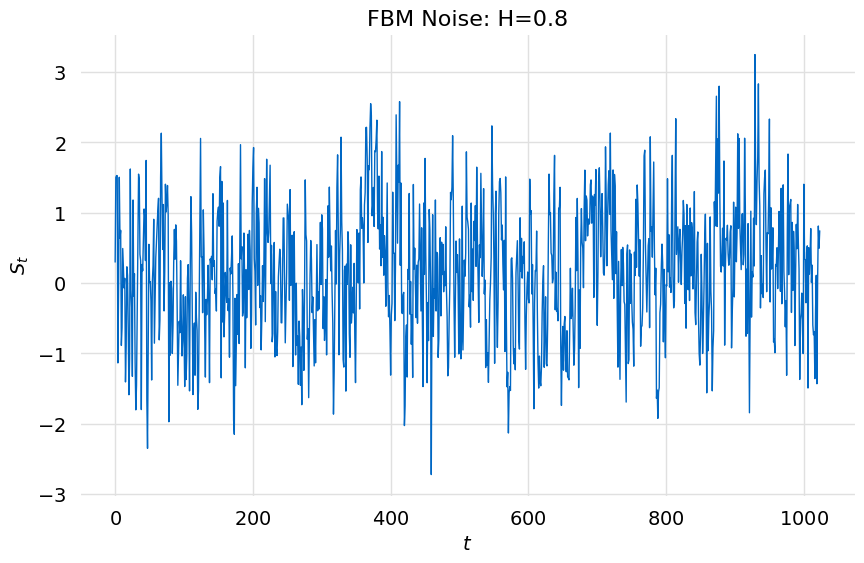

In [11]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

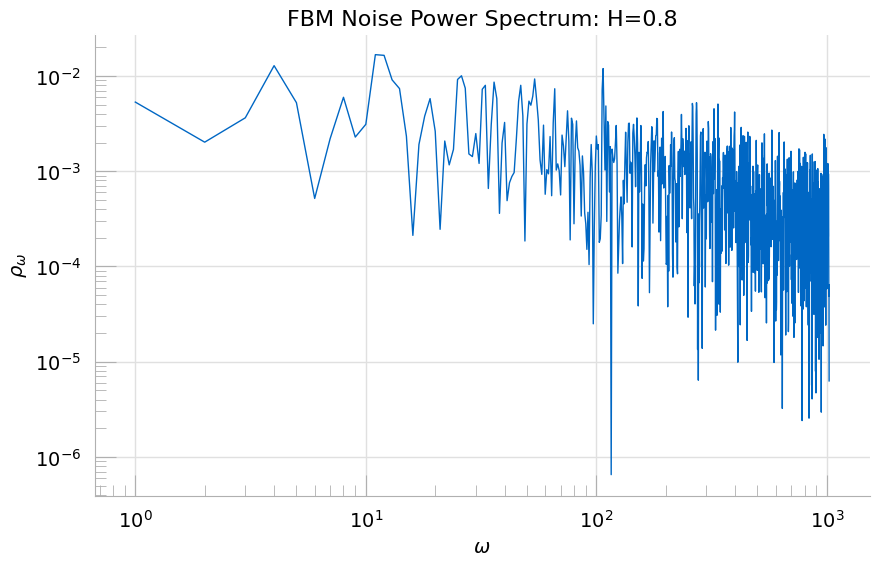

In [12]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [13]:
report, results = fbm.compute_H_estimate_periodogram(freq, ps)
report.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.204
Method:                 Least Squares   F-statistic:                     262.5
Date:                Thu, 06 Jul 2023   Prob (F-statistic):           1.03e-52
Time:                        19:04:42   Log-Likelihood:                -820.85
No. Observations:                1023   AIC:                             1646.
Df Residuals:                    1021   BIC:                             1656.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7091      0.103    -16.568      0.000      -1.912      -1.507
x1            -0.6397      0.039    -16.202      0.000      -0.717      -0.562
==============================================================================
Omnibus:                      160.589   Durbin-Watson:                   1.384
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              282.057
Skew:                          -0.978   Prob(JB):                     5.65e-62
Kurtosis:                       4.672   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
results.dict

{'est_model': 'OLS_SING_VAR',
 'param': {'Estimate': -0.6396952466293945,
  'Error': 0.03948279564606245,
  'Estimate Label': None,
  'Error Label': None},
 'const': {'Estimate': -1.7091131481503556,
  'Error': 0.10315735608250685,
  'Estimate Label': None,
  'Error Label': None},
 'r2': 0.20451932348837232,
 'transform': {'model': '$C\\omega^{1 - 2H}$',
  'param': {'Estimate': 0.8198476233146972,
   'Error': 0.019741397823031224,
   'Estimate Label': '$\\hat{Η}$',
   'Error Label': '$\\sigma_{\\hat{Η}}$'},
  'const': {'Estimate': 0.019538303516986488,
   'Error': 0.002015519733149871,
   'Estimate Label': '$\\hat{C}$',
   'Error Label': '$\\sigma_{\\hat{C}}$'}}}

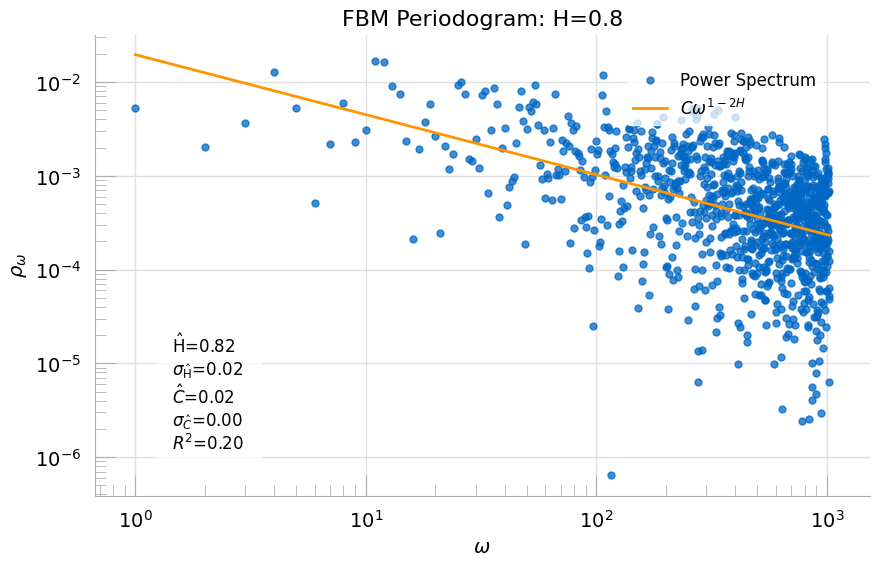

In [15]:
periodogram(ps, results, freq, title=f"FBM Periodogram: H={H}")

## Power Spectrum Simulation H=0.3

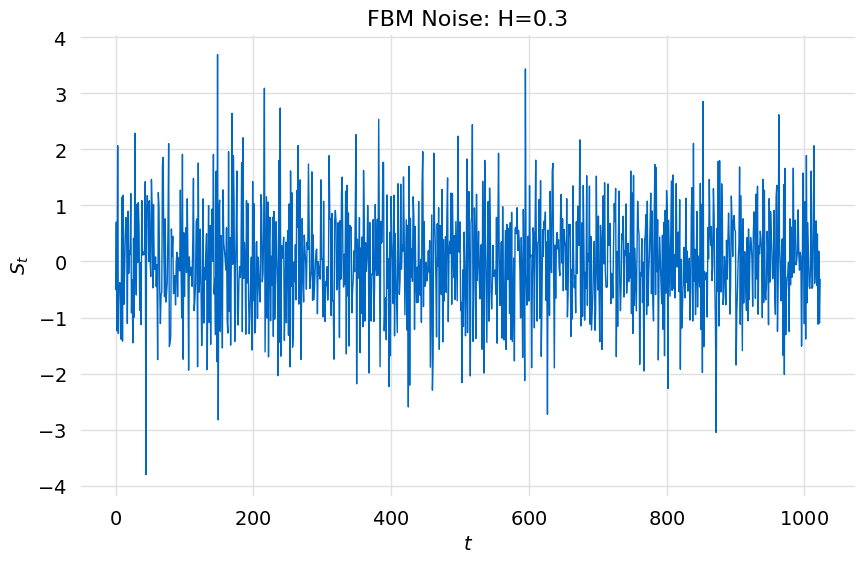

In [16]:
H = 0.3
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

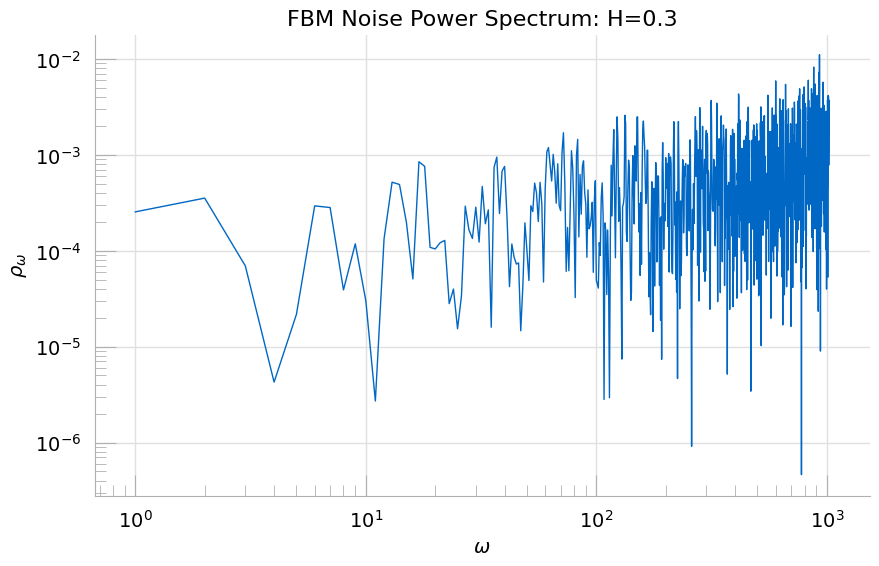

In [17]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [18]:
report, results = fbm.compute_H_estimate_periodogram(freq, ps)
report.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     153.9
Date:                Thu, 06 Jul 2023   Prob (F-statistic):           5.20e-33
Time:                        19:04:43   Log-Likelihood:                -863.29
No. Observations:                1023   AIC:                             1731.
Df Residuals:                    1021   BIC:                             1740.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.6343      0.108    -43.099      0.000      -4.845      -4.423
x1             0.5105      0.041     12.404      0.000       0.430       0.591
==============================================================================
Omnibus:                      149.130   Durbin-Watson:                   1.356
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              255.990
Skew:                          -0.926   Prob(JB):                     2.59e-56
Kurtosis:                       4.605   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
results.dict

{'est_model': 'OLS_SING_VAR',
 'param': {'Estimate': 0.5104870456354704,
  'Error': 0.04115511939375137,
  'Estimate Label': None,
  'Error Label': None},
 'const': {'Estimate': -4.634304443846458,
  'Error': 0.10752666411915249,
  'Estimate Label': None,
  'Error Label': None},
 'r2': 0.13095923415506783,
 'transform': {'model': '$C\\omega^{1 - 2H}$',
  'param': {'Estimate': 0.2447564771822648,
   'Error': 0.020577559696875684,
   'Estimate Label': '$\\hat{Η}$',
   'Error Label': '$\\sigma_{\\hat{Η}}$'},
  'const': {'Estimate': 2.3211091101773866e-05,
   'Error': 2.4958111967394876e-06,
   'Estimate Label': '$\\hat{C}$',
   'Error Label': '$\\sigma_{\\hat{C}}$'}}}

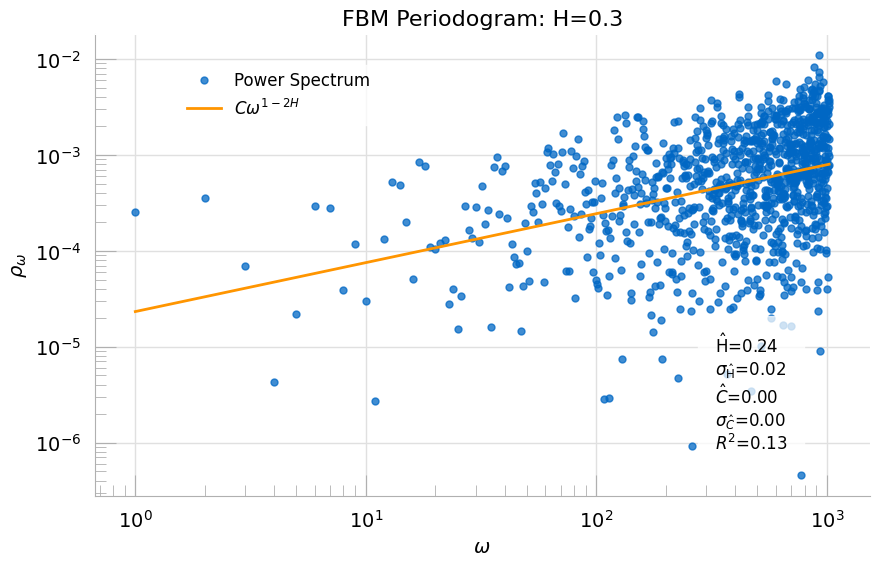

In [20]:
periodogram(ps, results, freq, title=f"FBM Periodogram: H={H}")